In [156]:
import pandas as pd
import numpy as np
np.random.seed(42)
num_customer = 2000

customer_ids =[f"cust_{i:04}" for i in range(1,num_customer + 1)]
age = np.random.randint(18,70,num_customer)
tenure_month = np.random.randint(1, 60, size =num_customer)

website_visits = np.random.randint(1, 31, size=num_customer)


purchase_frequency = np.round(website_visits * np.random.uniform(0.1, 0.6, size=num_customer)).astype(int)
purchase_frequency = np.where(purchase_frequency == 0, 1, purchase_frequency)

average_order_value = np.round(np.random.uniform(10, 500, size=num_customer), 2)
total_spending = np.round(purchase_frequency * average_order_value, 2)

recency_days = np.random.randint(1, 366, size=num_customer)

discount_usage = np.round(np.random.uniform(0, 1, size=num_customer), 2)

base_rating = 3 + (total_spending / 5000) - (recency_days / 100)
customer_rating = np.clip(np.round(base_rating + np.random.normal(0, 0.5, num_customer), 1),1, 5)

prob = 1 / (1 + np.exp(-(3 - (recency_days / 50) + (customer_rating * 0.5))))
purchase_likelihood = np.where(prob > 0.5, 1, 0)

df = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Age': age,
    'Tenure_Months': tenure_month,
    'Website_Visits_Per_Month': website_visits,
    'Purchase_Frequency': purchase_frequency,
    'Average_Order_Value': average_order_value,
    'Total_Spending': total_spending,
    'Recency_Days': recency_days,
    'Discount_Usage_Rate': discount_usage,
    'Customer_Rating': customer_rating,
    'Purchase_Likelihood': purchase_likelihood
})

df.to_csv('ecommerce_customer_data.csv', index=False)
print("Dataset completed")

print(df.head())
print(df.describe())
print(df.info())

Dataset completed
  Customer_ID  Age  Tenure_Months  Website_Visits_Per_Month  \
0   cust_0001   56             29                        19   
1   cust_0002   69             44                        15   
2   cust_0003   46             53                        28   
3   cust_0004   32             24                         8   
4   cust_0005   60             58                        20   

   Purchase_Frequency  Average_Order_Value  Total_Spending  Recency_Days  \
0                   9               361.90         3257.10           329   
1                   9                70.97          638.73            50   
2                  14               303.80         4253.20           337   
3                   4               279.67         1118.68            95   
4                  11               261.84         2880.24           268   

   Discount_Usage_Rate  Customer_Rating  Purchase_Likelihood  
0                 0.48              1.0                    0  
1                 0.

Best Parameters found: {'C': 100, 'penalty': 'l2'}
[*] Best Regularization Parameter (C) : 100
EVALUATION METRIC              | VALUE     
Model Accuracy                 | 0.9925 (99.2%)
Precision (Target Validation)  | 0.9902 (99.0%)
Recall (Sensitivity)           | 0.9951 (99.5%)
F1-Score (Balanced Mean)       | 0.9927
ROC-AUC Score                  | 0.9999
                          precision    recall  f1-score   support

Unlikely to Purchase (0)       0.99      0.99      0.99       196
  Likely to Purchase (1)       0.99      1.00      0.99       204

                accuracy                           0.99       400
               macro avg       0.99      0.99      0.99       400
            weighted avg       0.99      0.99      0.99       400

 -> High Precision Alert:
 -> High Recall Alert:
 -> Key Direct Indicator: 'Recency_Days' 


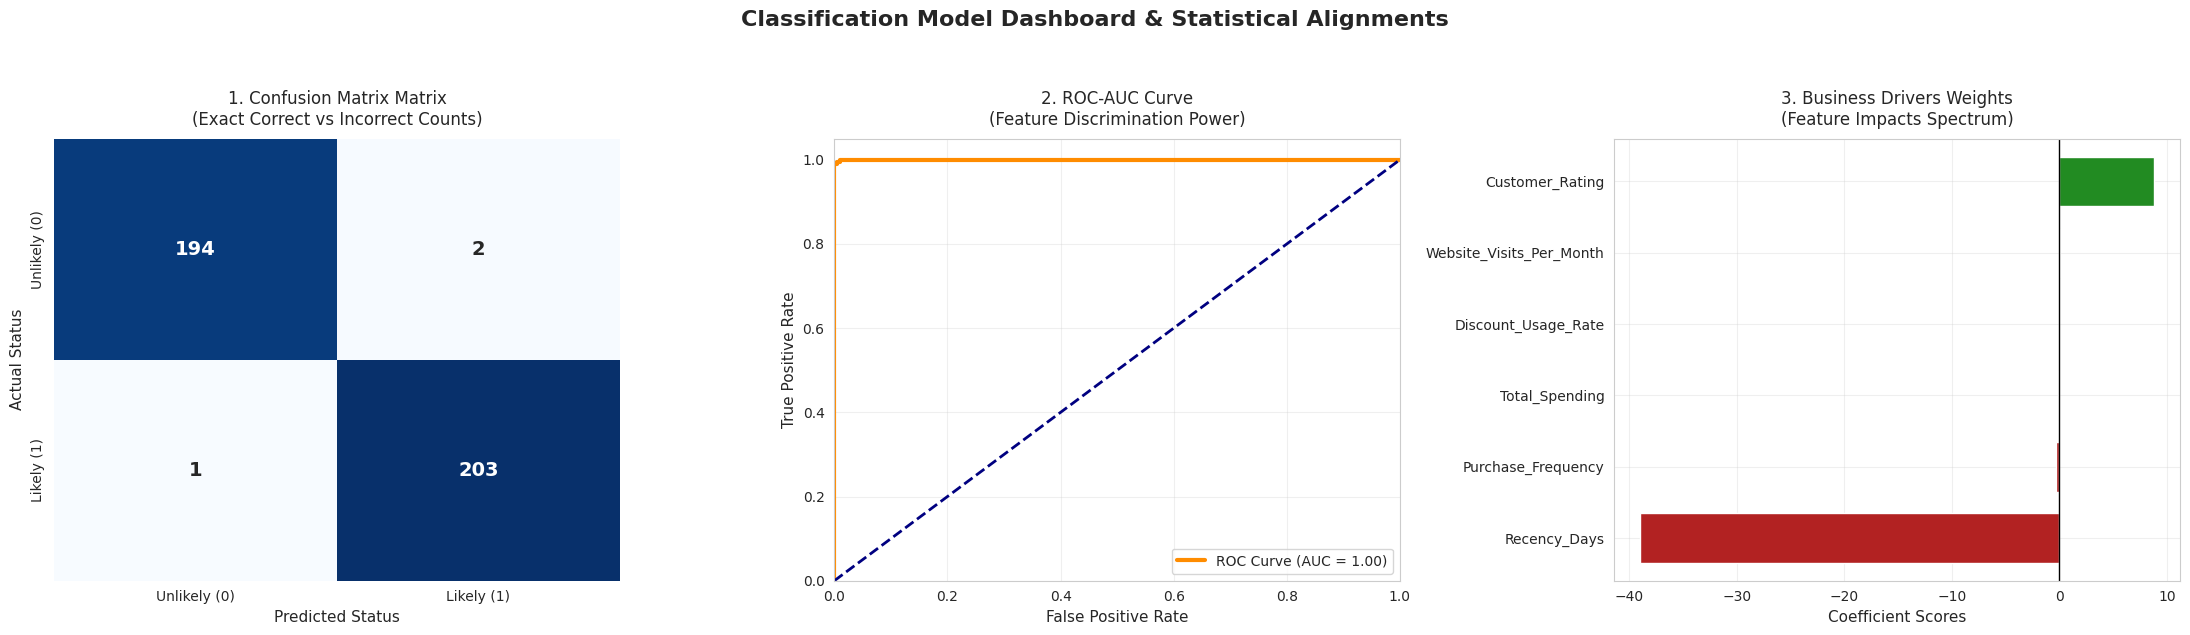

In [157]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

X = df[['Recency_Days', 'Purchase_Frequency', 'Total_Spending',
        'Customer_Rating', 'Website_Visits_Per_Month', 'Discount_Usage_Rate']]
y = df['Purchase_Likelihood']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Hyperparameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2']}

# Grid Search apply
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best Model selected
best_model = grid_search.best_estimator_
print(f"Best Parameters found: {grid_search.best_params_}")


y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# data aoutput and vizualized
print(f"[*] Best Regularization Parameter (C) : {grid_search.best_params_['C']}")

# Metrics calculation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"{'EVALUATION METRIC':<30} | {'VALUE':<10}")

print(f"{'Model Accuracy':<30} | {acc:.4f} ({acc*100:.1f}%)")
print(f"{'Precision (Target Validation)':<30} | {prec:.4f} ({prec*100:.1f}%)")
print(f"{'Recall (Sensitivity)':<30} | {rec:.4f} ({rec*100:.1f}%)")
print(f"{'F1-Score (Balanced Mean)':<30} | {f1:.4f}")
print(f"{'ROC-AUC Score':<30} | {roc_auc:.4f}")


print(classification_report(y_test, y_pred, target_names=['Unlikely to Purchase (0)', 'Likely to Purchase (1)']))

if prec > 0.80:
    print(" -> High Precision Alert:")
else:
    print(" -> Precision Notice: ")

if rec > 0.85:
    print(" -> High Recall Alert:")
print(f" -> Key Direct Indicator: '{X.columns[np.argmin(best_model.coef_[0])]}' ")
print("="*65)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Classification Model Dashboard & Statistical Alignments', fontsize=16, fontweight='bold', y=1.05)

# 1. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Unlikely (0)', 'Likely (1)'], yticklabels=['Unlikely (0)', 'Likely (1)'])
axes[0].set_title('1. Confusion Matrix Matrix\n(Exact Correct vs Incorrect Counts)', fontsize=12, pad=10)
axes[0].set_ylabel('Actual Status', fontsize=11)
axes[0].set_xlabel('Predicted Status', fontsize=11)

# 2. ROC-AUC Plot
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('2. ROC-AUC Curve\n(Feature Discrimination Power)', fontsize=12, pad=10)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# 3. Feature Importance Plot
coefficients = best_model.coef_[0]
feat_importances = pd.Series(coefficients, index=X.columns).sort_values()
colors = ['firebrick' if x < 0 else 'forestgreen' for x in feat_importances]
feat_importances.plot(kind='barh', color=colors, ax=axes[2], width=0.7)
axes[2].set_title('3. Business Drivers Weights\n(Feature Impacts Spectrum)', fontsize=12, pad=10)
axes[2].set_xlabel('Coefficient Scores', fontsize=11)
axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 DATASET OVERVIEW :
Total Customers: 2000
Total Features: 11

First 5 rows:
  Customer_ID  Age  Tenure_Months  Website_Visits_Per_Month  \
0   cust_0001   56             29                        19   
1   cust_0002   69             44                        15   
2   cust_0003   46             53                        28   
3   cust_0004   32             24                         8   
4   cust_0005   60             58                        20   

   Purchase_Frequency  Average_Order_Value  Total_Spending  Recency_Days  \
0                   9               361.90         3257.10           329   
1                   9                70.97          638.73            50   
2                  14               303.80         4253.20           337   
3                   4               279.67         1118.68            95   
4                  11               261.84         2880.24           268   

   Discount_Usage_Rate  Customer_Rating  Purchase_Likelihood  
0                 0.48   

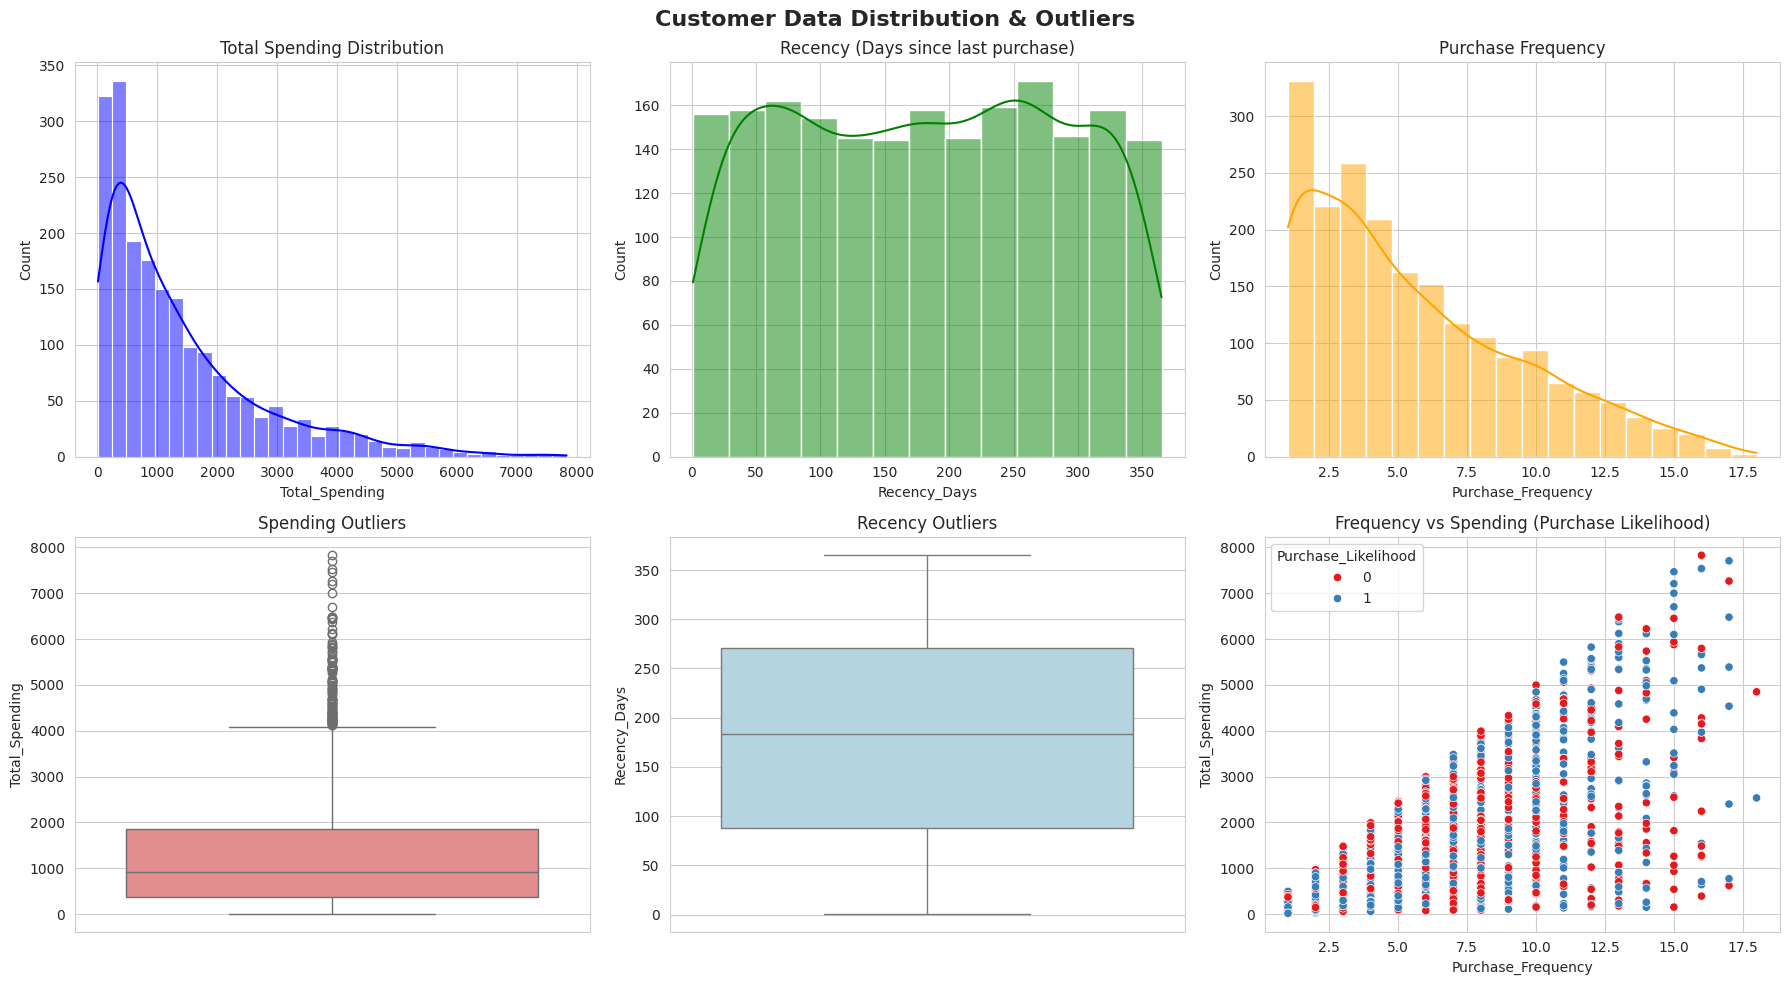

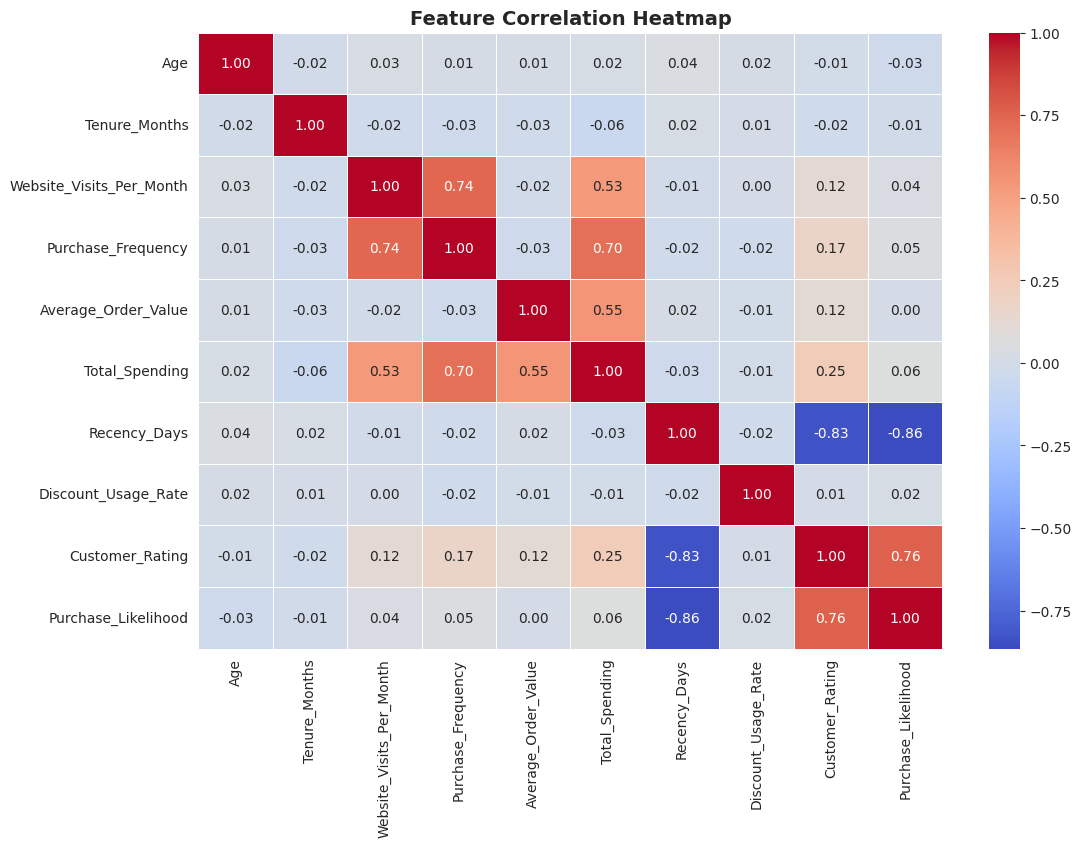

1. Spending vs Frequency Correlation: 0.70
2. Recency vs Spending Correlation: -0.03 )
3. Rating vs Spending Correlation: 0.25


In [158]:

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(" DATASET OVERVIEW :")
print(f"Total Customers: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

print("\n MISSING VALUES CHECK :")
print(df.isnull().sum())

print("\n STATISTICAL SUMMARY ")
print(df.describe())

# Visualization Grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Data Distribution & Outliers', fontsize=16, fontweight='bold')

# Spending Distribution
sns.histplot(df['Total_Spending'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Total Spending Distribution')

# 2. Recency Distribution
sns.histplot(df['Recency_Days'], kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Recency (Days since last purchase)')

# 3. Purchase Frequency
sns.histplot(df['Purchase_Frequency'], kde=True, ax=axes[0,2], color='orange')
axes[0,2].set_title('Purchase Frequency')

# 4. Boxplot - Spending Outliers
sns.boxplot(y=df['Total_Spending'], ax=axes[1,0], color='lightcoral')
axes[1,0].set_title('Spending Outliers')

# 5. Boxplot - Recency Outliers
sns.boxplot(y=df['Recency_Days'], ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Recency Outliers')

# 6. Scatter - Frequency vs Spending (colored by Likelihood)
sns.scatterplot(x='Purchase_Frequency', y='Total_Spending',
                hue='Purchase_Likelihood', data=df, ax=axes[1,2], palette='Set1')
axes[1,2].set_title('Frequency vs Spending (Purchase Likelihood)')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

# Key Insight print

print(f"1. Spending vs Frequency Correlation: {correlation.loc['Total_Spending', 'Purchase_Frequency']:.2f}")
print(f"2. Recency vs Spending Correlation: {correlation.loc['Total_Spending', 'Recency_Days']:.2f} )")
print(f"3. Rating vs Spending Correlation: {correlation.loc['Total_Spending', 'Customer_Rating']:.2f}")

RMSE: 513.72
R² Score: 0.8334
Best Alpha: 1.0
RMSE: 513.72
R² Score: 0.8334

=> R² Improvement: 0.00%


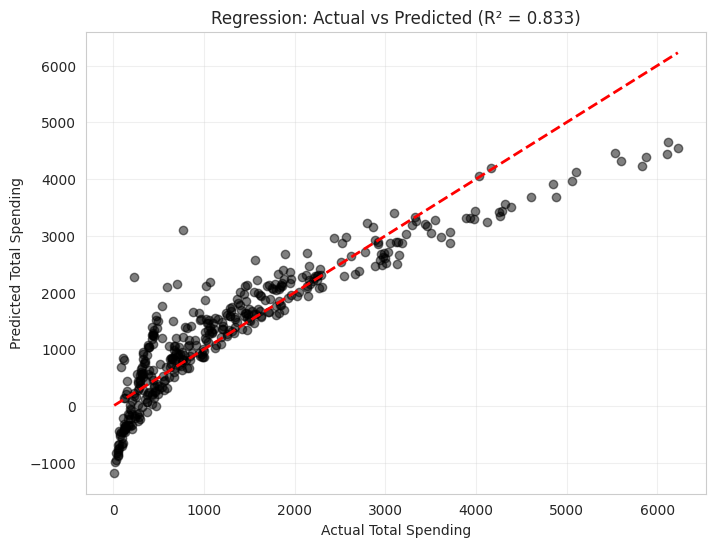

                    Feature  Coefficient
3        Purchase_Frequency   935.354646
4       Average_Order_Value   762.257425
7           Customer_Rating   206.745959
5              Recency_Days   135.103634
2  Website_Visits_Per_Month    18.860784
0                       Age    14.889599
6       Discount_Usage_Rate     7.143347
1             Tenure_Months   -33.126879


In [159]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

X_reg = df[['Age', 'Tenure_Months', 'Website_Visits_Per_Month', 'Purchase_Frequency',
            'Average_Order_Value', 'Recency_Days', 'Discount_Usage_Rate', 'Customer_Rating']]
y_reg = df['Total_Spending']

# Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scaling
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Baseline Ridge : alpha=1
ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_r_scaled, y_train_r)
y_pred_base = ridge_base.predict(X_test_r_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test_r, y_pred_base))
r2_base = r2_score(y_test_r, y_pred_base)

print(f"RMSE: {rmse_base:.2f}")
print(f"R² Score: {r2_base:.4f}")

#  Hyperparameter Tuning (GridSearch)
param_grid = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]}
ridge_cv = GridSearchCV(Ridge(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_r_scaled, y_train_r)

best_ridge = ridge_cv.best_estimator_
y_pred_tuned = best_ridge.predict(X_test_r_scaled)

rmse_tuned = np.sqrt(mean_squared_error(y_test_r, y_pred_tuned))
r2_tuned = r2_score(y_test_r, y_pred_tuned)

print(f"Best Alpha: {ridge_cv.best_params_['alpha']}")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"R² Score: {r2_tuned:.4f}")

# Improvement check
print(f"\n=> R² Improvement: {(r2_tuned - r2_base) * 100:.2f}%")

# -Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_tuned, alpha=0.5, color='black')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Actual Total Spending')
plt.ylabel('Predicted Total Spending')
plt.title(f'Regression: Actual vs Predicted (R² = {r2_tuned:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance in Regression
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': best_ridge.coef_
}).sort_values('Coefficient', ascending=False)


print(coef_df)

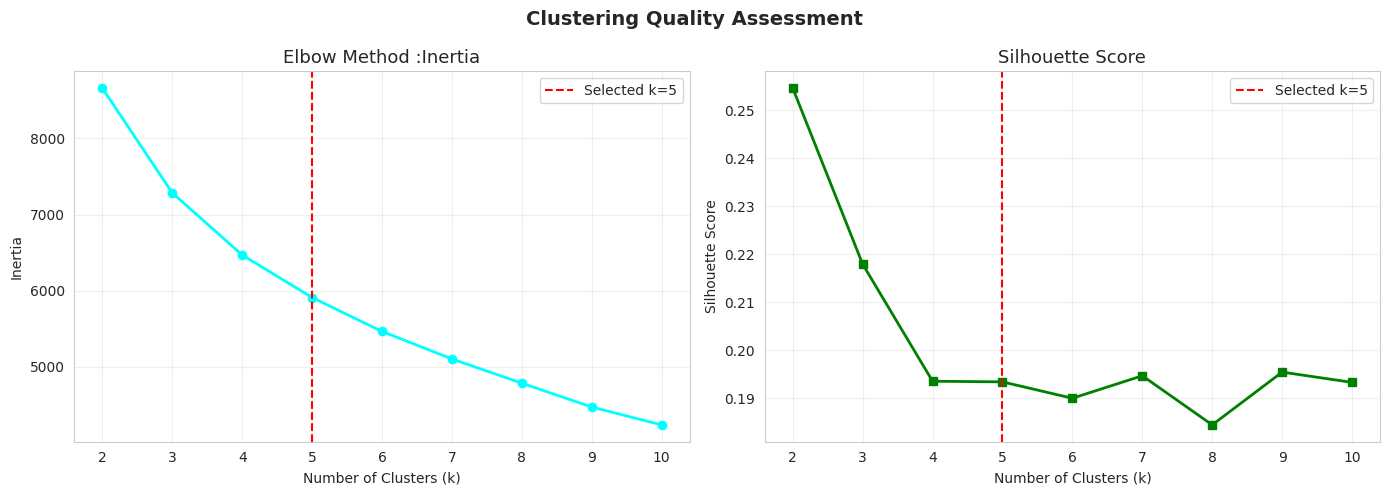

At k=5:
  - Inertia: 5909.87 
  - Silhouette Score: 0.1934 


In [165]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


cluster_feats = ['Recency_Days', 'Purchase_Frequency', 'Total_Spending',
                 'Average_Order_Value', 'Website_Visits_Per_Month', 'Discount_Usage_Rate']
X_cluster_eval = df[cluster_feats].copy()

for col in cluster_feats:
    Q1 = X_cluster_eval[col].quantile(0.25)
    Q3 = X_cluster_eval[col].quantile(0.75)
    X_cluster_eval[col] = np.clip(X_cluster_eval[col], Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1))

# Scaling
scaler_eval = StandardScaler()
X_scaled_eval = scaler_eval.fit_transform(X_cluster_eval)

inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_eval)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_eval, labels))


fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(2, 11), inertia_scores, marker='o', color='aqua', linewidth=2)
ax[0].set_title('Elbow Method :Inertia', fontsize=13)
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].grid(True, alpha=0.3)
# Mark k=5
ax[0].axvline(x=5, color='red', linestyle='--', label='Selected k=5')
ax[0].legend()

ax[1].plot(range(2, 11), silhouette_scores, marker='s', color='green', linewidth=2)
ax[1].set_title('Silhouette Score', fontsize=13)
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True, alpha=0.3)
ax[1].axvline(x=5, color='red', linestyle='--', label='Selected k=5')
ax[1].legend()

plt.suptitle('Clustering Quality Assessment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print justification

print(f"At k=5:")
print(f"  - Inertia: {inertia_scores[3]:.2f} ")
print(f"  - Silhouette Score: {silhouette_scores[3]:.4f} ")



 Using features: ['Recency_Days', 'Purchase_Frequency', 'Total_Spending', 'Average_Order_Value', 'Website_Visits_Per_Month', 'Discount_Usage_Rate']
 K-Means clustering complete!

 Raw Cluster Stats:
 Cluster  Total_Spending  Recency_Days  Discount_Usage_Rate  Purchase_Frequency  Count
       0          975.95        186.35                 0.50                8.25    438
       1         3697.41        166.81                 0.50               10.24    373
       2          242.54        186.45                 0.51                2.48    409
       3          951.54         74.22                 0.55                2.96    347
       4         1126.39        271.92                 0.45                3.27    433
   Cluster 1 -> 1. High-Value Loyal
      Customers: 373  Avg Spend: $3697  Recency: 167 days  Freq: 10.2 Discount: 50%
   Cluster 4 -> 4. At-Risk (Churn)
      Customers: 433  Avg Spend: $1126  Recency: 272 days  Freq: 3.3 Discount: 45%
   Cluster 3 -> 3. Discount-Driven
     

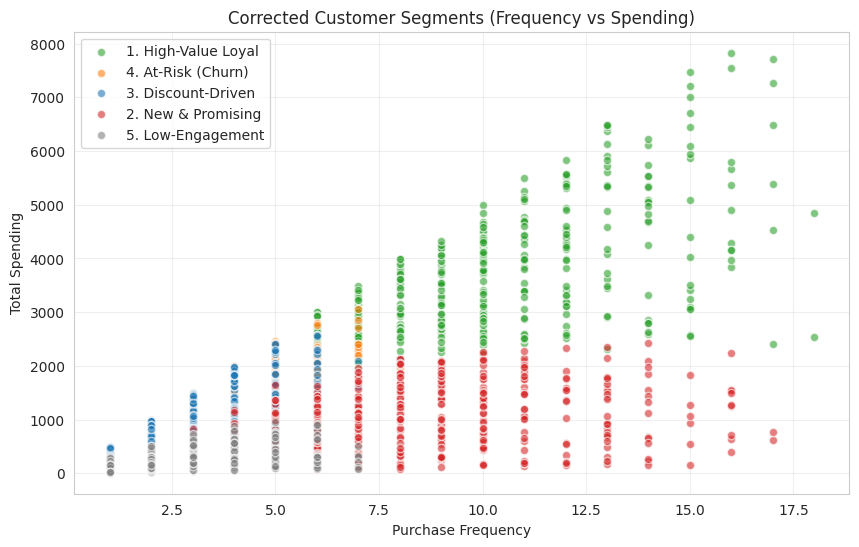

In [161]:

cluster_feats = ['Recency_Days', 'Purchase_Frequency', 'Total_Spending',
                 'Average_Order_Value', 'Website_Visits_Per_Month', 'Discount_Usage_Rate']

print("\n Using features:", cluster_feats)


X_clust = df[cluster_feats].copy()
for col in cluster_feats:
    Q1 = X_clust[col].quantile(0.25)
    Q3 = X_clust[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_clust[col] = np.clip(X_clust[col], lower, upper)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(" K-Means clustering complete!")


cluster_stats = df.groupby('Cluster').agg({
    'Total_Spending': 'mean',
    'Recency_Days': 'mean',
    'Discount_Usage_Rate': 'mean',
    'Purchase_Frequency': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Count'}).round(2).reset_index()

print("\n Raw Cluster Stats:")
print(cluster_stats.to_string(index=False))

loyal_cluster = cluster_stats.loc[cluster_stats['Total_Spending'].idxmax(), 'Cluster']

# Oldest customers (High Recency) -> At-Risk
atrisk_cluster = cluster_stats.loc[cluster_stats['Recency_Days'].idxmax(), 'Cluster']

# Highest Discount Users -> Discount-Driven
discount_cluster = cluster_stats.loc[cluster_stats['Discount_Usage_Rate'].idxmax(), 'Cluster']

# Among remaining, highest Frequency -> New & Promising
remaining = cluster_stats[~cluster_stats['Cluster'].isin([loyal_cluster, atrisk_cluster, discount_cluster])]
if not remaining.empty:
    promising_cluster = remaining.loc[remaining['Purchase_Frequency'].idxmax(), 'Cluster']
else:
    promising_cluster = None

# Last remaining -> Low-Engagement
all_clusters = set(cluster_stats['Cluster'])
assigned = {loyal_cluster, atrisk_cluster, discount_cluster}
if promising_cluster is not None:
    assigned.add(promising_cluster)
low_clusters = list(all_clusters - assigned)
low_cluster = low_clusters[0] if low_clusters else None

# Final Mapping
final_mapping = {
    loyal_cluster: "1. High-Value Loyal",
    atrisk_cluster: "4. At-Risk (Churn)",
    discount_cluster: "3. Discount-Driven",
}
if promising_cluster is not None:
    final_mapping[promising_cluster] = "2. New & Promising"
if low_cluster is not None:
    final_mapping[low_cluster] = "5. Low-Engagement"

# Apply to dataframe
df['Segment_Name'] = df['Cluster'].map(final_mapping)

for cluster, name in final_mapping.items():
    stats = cluster_stats[cluster_stats['Cluster'] == cluster]
    spend = stats['Total_Spending'].values[0]
    rec = stats['Recency_Days'].values[0]
    freq = stats['Purchase_Frequency'].values[0]
    disc = stats['Discount_Usage_Rate'].values[0]
    cnt = stats['Count'].values[0]
    print(f"   Cluster {cluster} -> {name}")
    print(f"      Customers: {cnt}  Avg Spend: ${spend:.0f}  Recency: {rec:.0f} days  Freq: {freq:.1f} Discount: {disc:.0%}")

print("\n Segment Distribution:")
print(df['Segment_Name'].value_counts())

export_cols = ['Customer_ID', 'Cluster', 'Segment_Name', 'Total_Spending',
               'Purchase_Frequency', 'Recency_Days', 'Discount_Usage_Rate',
               'Customer_Rating', 'Purchase_Likelihood']

# Ensure only existing columns are exported
export_cols_existing = [c for c in export_cols if c in df.columns]
df[export_cols_existing].to_csv('customer_segmentation_final.csv', index=False)

print(f"   Total rows: {len(df)}")

plt.figure(figsize=(10, 6))
colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728', '#7f7f7f']
for i, (cluster, name) in enumerate(final_mapping.items()):
    sub = df[df['Cluster'] == cluster]
    plt.scatter(sub['Purchase_Frequency'], sub['Total_Spending'],
                label=name, color=colors[i % len(colors)], alpha=0.6, edgecolors='w')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.title('Corrected Customer Segments (Frequency vs Spending)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


 CORRECT CUSTOMER SEGMENT PROFILES
 Cluster        Segment_Name  Count  Avg_Spending  Total_Revenue  Revenue_Share_%  Avg_Recency  Avg_Freq  Avg_Discount
       1 1. High-Value Loyal    373       3697.41     1379134.04        50.634381       166.81     10.24          0.50
       4  4. At-Risk (Churn)    433       1126.39      487727.60        17.906733       271.92      3.27          0.45
       0  2. New & Promising    438        975.95      427466.15        15.694257       186.35      8.25          0.50
       3  3. Discount-Driven    347        951.54      330183.87        12.122575        74.22      2.96          0.55
       2   5. Low-Engagement    409        242.54       99199.02         3.642054       186.45      2.48          0.51


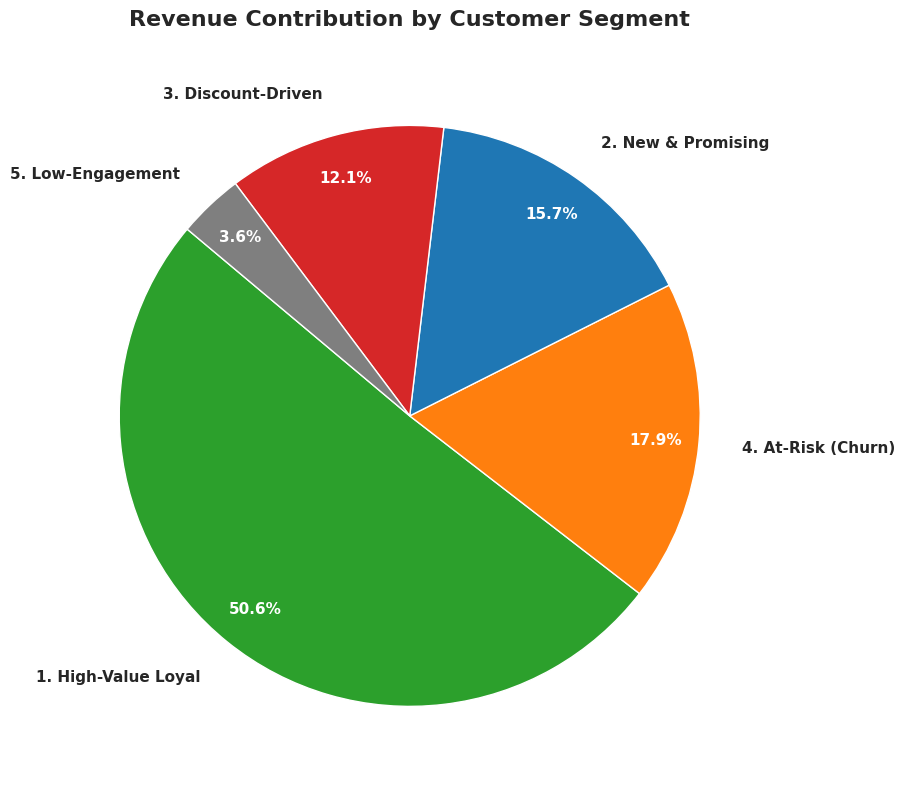


 Segment Mapping Applied:
   Cluster 1 -> 1. High-Value Loyal (Avg Spend: $3697)
   Cluster 0 -> 2. New & Promising (Avg Spend: $976)
   Cluster 3 -> 3. Discount-Driven (Avg Spend: $952)
   Cluster 4 -> 4. At-Risk (Churn) (Avg Spend: $1126)
   Cluster 2 -> 5. Low-Engagement (Avg Spend: $243)


In [162]:

if 'Cluster' not in df.columns:
    raise KeyError("Run the clustering cell (Cell 10) before this one.")

segment_agg = df.groupby('Cluster').agg({
    'Customer_ID': 'count',
    'Total_Spending': ['mean', 'sum'],
    'Purchase_Frequency': 'mean',
    'Recency_Days': 'mean',
    'Average_Order_Value': 'mean',
    'Discount_Usage_Rate': 'mean',
    'Customer_Rating': 'mean',
    'Website_Visits_Per_Month': 'mean'
}).round(2)

# Flatten columns
segment_agg.columns = ['Count', 'Avg_Spending', 'Total_Revenue', 'Avg_Freq',
                       'Avg_Recency', 'Avg_Order', 'Avg_Discount', 'Avg_Rating', 'Avg_Visits']

# Revenue Contribution
segment_agg['Revenue_Share_%'] = (segment_agg['Total_Revenue'] / segment_agg['Total_Revenue'].sum()) * 100

# Sort by Revenue descending
segment_agg = segment_agg.sort_values('Total_Revenue', ascending=False).reset_index()

# These automatically find the extreme clusters
loyal_cluster = segment_agg.loc[segment_agg['Avg_Spending'].idxmax(), 'Cluster']
atrisk_cluster = segment_agg.loc[segment_agg['Avg_Recency'].idxmax(), 'Cluster']
discount_cluster = segment_agg.loc[segment_agg['Avg_Discount'].idxmax(), 'Cluster']

# Remaining clusters: assign "New & Promising" to the one with highest frequency
remaining = segment_agg[~segment_agg['Cluster'].isin([loyal_cluster, atrisk_cluster, discount_cluster])]
if not remaining.empty:
    promising_cluster = remaining.loc[remaining['Avg_Freq'].idxmax(), 'Cluster']
else:
    promising_cluster = None

# Last remaining cluster = Low-Engagement
all_clusters = set(segment_agg['Cluster'])
assigned = {loyal_cluster, atrisk_cluster, discount_cluster}
if promising_cluster is not None:
    assigned.add(promising_cluster)
low_clusters = list(all_clusters - assigned)
low_cluster = low_clusters[0] if low_clusters else None

# Build mapping dictionary
name_mapping = {}
name_mapping[loyal_cluster] = "1. High-Value Loyal"
if promising_cluster is not None:
    name_mapping[promising_cluster] = "2. New & Promising"
name_mapping[discount_cluster] = "3. Discount-Driven"
name_mapping[atrisk_cluster] = "4. At-Risk (Churn)"
if low_cluster is not None:
    name_mapping[low_cluster] = "5. Low-Engagement"

# Apply mapping to segment_agg
segment_agg['Segment_Name'] = segment_agg['Cluster'].map(name_mapping)



print(" CORRECT CUSTOMER SEGMENT PROFILES")
print(segment_agg[['Cluster', 'Segment_Name', 'Count', 'Avg_Spending', 'Total_Revenue',
                   'Revenue_Share_%', 'Avg_Recency', 'Avg_Freq', 'Avg_Discount']].to_string(index=False))

#  PLOT CLEAN PIE CHART ----
plt.figure(figsize=(10, 8))
colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728', '#7f7f7f']

patches, texts, autotexts = plt.pie(
    segment_agg['Revenue_Share_%'],
    labels=segment_agg['Segment_Name'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(segment_agg)],
    textprops={'fontsize': 11, 'weight': 'bold'},
    labeldistance=1.15,
    pctdistance=0.85
)


for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title('Revenue Contribution by Customer Segment', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


print("\n Segment Mapping Applied:")
for cluster, name in name_mapping.items():
    row = segment_agg[segment_agg['Cluster'] == cluster]
    print(f"   Cluster {cluster} -> {name} (Avg Spend: ${row['Avg_Spending'].values[0]:.0f})")

In [163]:

df['Segment_Name'] = df['Cluster'].map(dict(zip(segment_agg['Cluster'], segment_agg['Segment_Name'])))

for  idx,row in segment_agg.iterrows():
    seg_name = row['Segment_Name']
    count = row['Count']
    rev_share = row['Revenue_Share_%']
    avg_spend = row['Avg_Spending']
    avg_rec = row['Avg_Recency']
    avg_disc = row['Avg_Discount']

    print(f"\n {seg_name} (Cluster {row['Cluster']})")
    print(f"    Size: {count} customers Revenue Share: {rev_share:.1f}%  Avg Spend: ${avg_spend:.0f}")
    print(f"    Recency: {avg_rec:.0f} days  Discount Usage: {avg_disc:.0%}")




 1. High-Value Loyal (Cluster 1)
    Size: 373 customers Revenue Share: 50.6%  Avg Spend: $3697
    Recency: 167 days  Discount Usage: 50%

 4. At-Risk (Churn) (Cluster 4)
    Size: 433 customers Revenue Share: 17.9%  Avg Spend: $1126
    Recency: 272 days  Discount Usage: 45%

 2. New & Promising (Cluster 0)
    Size: 438 customers Revenue Share: 15.7%  Avg Spend: $976
    Recency: 186 days  Discount Usage: 50%

 3. Discount-Driven (Cluster 3)
    Size: 347 customers Revenue Share: 12.1%  Avg Spend: $952
    Recency: 74 days  Discount Usage: 55%

 5. Low-Engagement (Cluster 2)
    Size: 409 customers Revenue Share: 3.6%  Avg Spend: $243
    Recency: 186 days  Discount Usage: 51%


In [164]:

if 'Segment_Name' not in df.columns:
    df['Segment_Name'] = df['Cluster'].map(dict(zip(segment_agg['Cluster'], segment_agg['Segment_Name'])))

export_df = df[['Customer_ID', 'Cluster', 'Segment_Name', 'Total_Spending', 'Purchase_Frequency',
                'Recency_Days', 'Discount_Usage_Rate', 'Customer_Rating', 'Purchase_Likelihood']]

# Save to CSV
export_df.to_csv('customer_segmentation_final.csv', index=False)
print(f"   Total rows exported: {len(export_df)}")
print("\nSample of exported data:")
print(export_df.head())

# Final Summary Count
print(df['Segment_Name'].value_counts())

   Total rows exported: 2000

Sample of exported data:
  Customer_ID  Cluster         Segment_Name  Total_Spending  \
0   cust_0001        1  1. High-Value Loyal         3257.10   
1   cust_0002        0   2. New & Promising          638.73   
2   cust_0003        1  1. High-Value Loyal         4253.20   
3   cust_0004        3   3. Discount-Driven         1118.68   
4   cust_0005        1  1. High-Value Loyal         2880.24   

   Purchase_Frequency  Recency_Days  Discount_Usage_Rate  Customer_Rating  \
0                   9           329                 0.48              1.0   
1                   9            50                 0.76              2.3   
2                  14           337                 0.26              1.0   
3                   4            95                 0.48              2.0   
4                  11           268                 0.99              1.5   

   Purchase_Likelihood  
0                    0  
1                    1  
2                    0  
3  